# mcengine walkthrough

Pricing a European call with every estimator, then path-dependent and American options, each next to an independent reference.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mcengine.reporting.style import apply_style, PALETTE

apply_style()
%matplotlib inline

In [2]:
from mcengine import GBM, EuropeanOption, price_mc, price_analytic

model = GBM(s0=100.0, r=0.05, sigma=0.2)
call = EuropeanOption(strike=100.0, maturity=1.0)
ref = price_analytic(model, call).price
for method in ("plain", "antithetic", "cv", "is", "qmc"):
    n = 16 * 2**13 if method == "qmc" else 100_000
    res = price_mc(model, call, n_paths=n, method=method, seed=7)
    print(
        f"{res.method:14s} {res.price:.5f} +/- {res.std_error:.5f}   "
        f"error {res.error_in_se(ref):+.2f} SE"
    )
print(f"Black-Scholes  {ref:.5f}")

mc-plain       10.40666 +/- 0.04635   error -0.95 SE
mc-antithetic  10.41601 +/- 0.03273   error -1.06 SE
mc-cv          10.42988 +/- 0.01774   error -1.17 SE
mc-is          10.39383 +/- 0.05559   error -1.02 SE
qmc-sobol-bb   10.45007 +/- 0.00034   error -1.49 SE
Black-Scholes  10.45058


## Convergence of the plain estimator

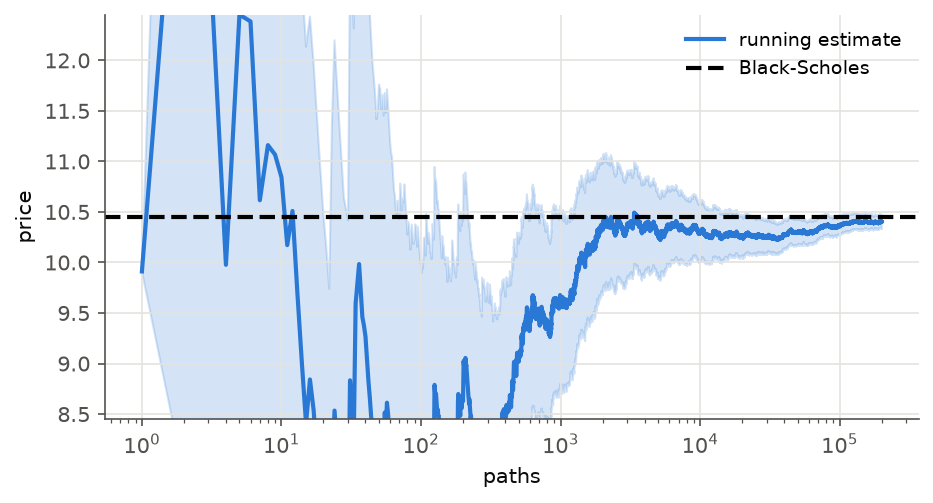

In [3]:
from mcengine.engines.monte_carlo import simulate_discounted_payoffs

y = simulate_discounted_payoffs(model, call, 200_000, seed=1)
k = np.arange(1, y.size + 1)
mean = np.cumsum(y) / k
se = np.sqrt(np.maximum(np.cumsum(y**2) / k - mean**2, 0) / k)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.fill_between(k, mean - 1.96 * se, mean + 1.96 * se, alpha=0.2, color=PALETTE[0])
ax.plot(k, mean, color=PALETTE[0], label="running estimate")
ax.axhline(ref, color="k", ls="--", label="Black-Scholes")
ax.set_xscale("log")
ax.set_ylim(ref - 2, ref + 2)
ax.set_xlabel("paths")
ax.set_ylabel("price")
ax.legend();

## Arithmetic Asian: geometric control variate vs recursive convolution

In [4]:
from mcengine.products.asian import AsianOption
from mcengine.engines.convolution import asian_arithmetic_price

asian = AsianOption(100.0, 1.0, n_fixings=12)
ref_asian = asian_arithmetic_price(model, asian)
for method in ("plain", "cv"):
    res = price_mc(model, asian, n_paths=100_000, method=method, seed=3)
    print(res, f"error {res.error_in_se(ref_asian):+.2f} SE", res.diagnostics)
print("recursive convolution:", round(ref_asian, 6))

mc-plain: 6.163549 +/- 0.026957 (95% CI [6.110715, 6.216384], n=100000) error +0.28 SE {}
mc-cv: 6.157178 +/- 0.000752 (95% CI [6.155704, 6.158652], n=100000) error +1.51 SE {'beta': 1.031747483327568, 'vr_factor': 1285.0799303796618, 'corr': 0.9996108434220656}
recursive convolution: 6.156039


## Barrier: Brownian-bridge estimator vs Reiner-Rubinstein

In [5]:
from mcengine.products.barrier import BarrierOption

dao = BarrierOption(
    100.0,
    1.0,
    90.0,
    "down-and-out",
    "call",
    n_monitoring=50,
    correction="bridge",
    correction_sigma=0.2,
)
res = price_mc(model, dao, n_paths=100_000, seed=5)
ref_b = price_analytic(model, dao).price
print(res, f"reference {ref_b:.5f}, error {res.error_in_se(ref_b):+.2f} SE")

mc-plain: 8.569600 +/- 0.045495 (95% CI [8.480431, 8.658769], n=100000) reference 8.66547, error -2.11 SE


## American put: Longstaff-Schwartz vs Bermudan CRR tree

In [6]:
from mcengine.products.american import AmericanOption
from mcengine.engines.lsm import price_lsm
from mcengine.engines.tree import price_tree

put = AmericanOption(40.0, 1.0, "put", n_exercise=50)
ls_model = GBM(36.0, 0.06, 0.2)
lsm = price_lsm(ls_model, put, n_paths=100_000, seed=11)
tree = price_tree(ls_model, put, n_steps=5000)
print(lsm, "| tree:", round(tree.price, 5), f"| error {lsm.error_in_se(tree.price):+.2f} SE")
print("in-sample (upward-biased) value:", round(lsm.diagnostics["in_sample_price"], 5))

lsm: 4.470251 +/- 0.009281 (95% CI [4.452061, 4.488440], n=100000) | tree: 4.47781 | error -0.81 SE
in-sample (upward-biased) value: 4.4756
